In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

print("libraries loaded!")

libraries loaded!


In [3]:
# loading all pkl files we saved in session 1
with open('../outputs/X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)

with open('../outputs/X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open('../outputs/y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open('../outputs/y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (144415, 115)
Test: (36104, 115)


In [4]:
# starting with logistic regression as our baseline model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression training done!")

Logistic Regression training done!


In [5]:
# predicting on test data
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print("Predictions done!")

Predictions done!


In [6]:
# checking how well our baseline model performed
print("=== Logistic Regression Results ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall:    {recall_score(y_test, lr_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_prob):.4f}")

=== Logistic Regression Results ===
Accuracy:  0.9737
Precision: 0.9548
Recall:    0.9992
F1 Score:  0.9765
ROC-AUC:   0.9820


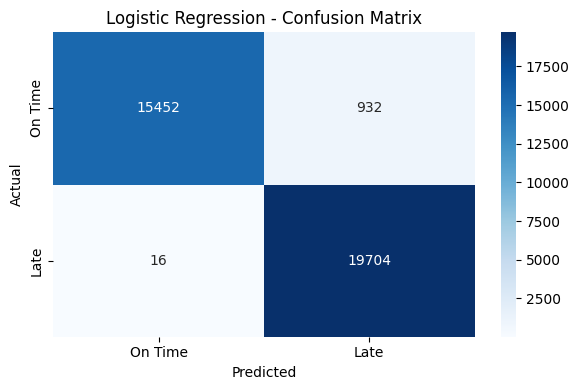

In [7]:
# confusion matrix shows where model is making mistakes
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Late'],
            yticklabels=['On Time', 'Late'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/lr_confusion_matrix.png')
plt.show()

In [8]:
# delay_gap is causing data leakage
# in real world we don't know actual shipping days before delivery
# so we need to remove it

with open('../outputs/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print("delay_gap in features:", 'delay_gap' in feature_names)

delay_gap in features: True


In [9]:
import pandas as pd
import pickle

# reload original csv
df = pd.read_csv('../data/APL_Logistics.csv', encoding='latin1')

# same cleaning as session 1
cols_to_drop = [
    'Customer Fname', 'Customer Lname', 'Customer Street',
    'Customer Zipcode', 'Customer Id', 'Order Customer Id',
    'Delivery Status', 'Order Status', 'Customer City',
    'Customer State', 'Order City', 'Order Country',
    'Order State', 'Product Name'
]
df.drop(columns=cols_to_drop, inplace=True)

# feature engineering - without delay_gap this time
df['shipping_pressure'] = df['Order Item Quantity'] / (df['Days for shipment (scheduled)'] + 1)
df['order_complexity'] = (
    df['Order Item Quantity'] *
    df['Order Item Product Price'] *
    (1 + df['Order Item Discount Rate'])
)
df['loss_order'] = (df['Benefit per order'] < 0).astype(int)

# encoding
cols_to_encode = [
    'Type', 'Customer Segment', 'Shipping Mode',
    'Market', 'Department Name', 'Order Region',
    'Customer Country', 'Category Name'
]
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

print(f"Columns: {df.shape[1]}")
print(f"delay_gap removed: {'delay_gap' not in df.columns}")

Columns: 115
delay_gap removed: True


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Late_delivery_risk'])
y = df['Late_delivery_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features: {X_train_scaled.shape[1]}")
print("Ready to train!")

Features: 114
Ready to train!


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression (Fixed) ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall:    {recall_score(y_test, lr_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_prob):.4f}")

=== Logistic Regression (Fixed) ===
Accuracy:  0.9737
Precision: 0.9548
Recall:    0.9991
F1 Score:  0.9765
ROC-AUC:   0.9820


In [12]:
# checking which features are most correlated with late delivery
correlations = pd.DataFrame(X, columns=X.columns)
correlations['Late_delivery_risk'] = y.values

corr_values = correlations.corr()['Late_delivery_risk'].abs().sort_values(ascending=False)
print("Top 15 features correlated with late delivery:")
print(corr_values.head(15))

Top 15 features correlated with late delivery:
Late_delivery_risk               1.000000
Shipping Mode_Standard Class     0.409749
Days for shipping (real)         0.401415
Days for shipment (scheduled)    0.369352
Shipping Mode_Second Class       0.215689
shipping_pressure                0.126710
Type_TRANSFER                    0.078046
Shipping Mode_Same Day           0.043595
Type_DEBIT                       0.037884
Type_PAYMENT                     0.029746
Order Region_Western Europe      0.008611
Order Region_Caribbean           0.007735
Order Region_South Asia          0.006111
Order Region_Central Africa      0.006093
Market_LATAM                     0.006025
Name: Late_delivery_risk, dtype: float64


In [13]:
# removing actual shipping days - not available before delivery
X_clean = X.drop(columns=['Days for shipping (real)'])

print(f"Features: {X_clean.shape[1]}")

# check top correlations again
corr2 = X_clean.copy()
corr2['Late_delivery_risk'] = y.values
corr_values2 = corr2.corr()['Late_delivery_risk'].abs().sort_values(ascending=False)
print("\nTop 10 features now:")
print(corr_values2.head(10))

Features: 113

Top 10 features now:
Late_delivery_risk               1.000000
Shipping Mode_Standard Class     0.409749
Days for shipment (scheduled)    0.369352
Shipping Mode_Second Class       0.215689
shipping_pressure                0.126710
Type_TRANSFER                    0.078046
Shipping Mode_Same Day           0.043595
Type_DEBIT                       0.037884
Type_PAYMENT                     0.029746
Order Region_Western Europe      0.008611
Name: Late_delivery_risk, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train2_scaled, y_train2)

lr2_pred = lr2.predict(X_test2_scaled)
lr2_prob = lr2.predict_proba(X_test2_scaled)[:, 1]

print("=== Logistic Regression (Final - No Leakage) ===")
print(f"Accuracy:  {accuracy_score(y_test2, lr2_pred):.4f}")
print(f"Precision: {precision_score(y_test2, lr2_pred):.4f}")
print(f"Recall:    {recall_score(y_test2, lr2_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test2, lr2_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test2, lr2_prob):.4f}")

=== Logistic Regression (Final - No Leakage) ===
Accuracy:  0.6934
Precision: 0.8354
Recall:    0.5462
F1 Score:  0.6606
ROC-AUC:   0.7382


In [15]:
# saving clean data without leakage for next models
with open('../outputs/X_train_final.pkl', 'wb') as f:
    pickle.dump(X_train2_scaled, f)

with open('../outputs/X_test_final.pkl', 'wb') as f:
    pickle.dump(X_test2_scaled, f)

with open('../outputs/y_train_final.pkl', 'wb') as f:
    pickle.dump(y_train2, f)

with open('../outputs/y_test_final.pkl', 'wb') as f:
    pickle.dump(y_test2, f)

with open('../outputs/scaler_final.pkl', 'wb') as f:
    pickle.dump(scaler2, f)

with open('../outputs/feature_names_final.pkl', 'wb') as f:
    pickle.dump(X_clean.columns.tolist(), f)

with open('../outputs/lr_model.pkl', 'wb') as f:
    pickle.dump(lr2, f)

print("All files saved!")
print(f"Total features: {X_clean.shape[1]}")

All files saved!
Total features: 113


In [16]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators = number of trees in the forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # use all CPU cores - faster training
)

rf_model.fit(X_train2_scaled, y_train2)
print("Random Forest training done!")


Random Forest training done!


In [17]:
rf_pred = rf_model.predict(X_test2_scaled)
rf_prob = rf_model.predict_proba(X_test2_scaled)[:, 1]

print("=== Random Forest Results ===")
print(f"Accuracy:  {accuracy_score(y_test2, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test2, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test2, rf_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test2, rf_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test2, rf_prob):.4f}")

=== Random Forest Results ===
Accuracy:  0.6870
Precision: 0.7591
Recall:    0.6253
F1 Score:  0.6857
ROC-AUC:   0.7499


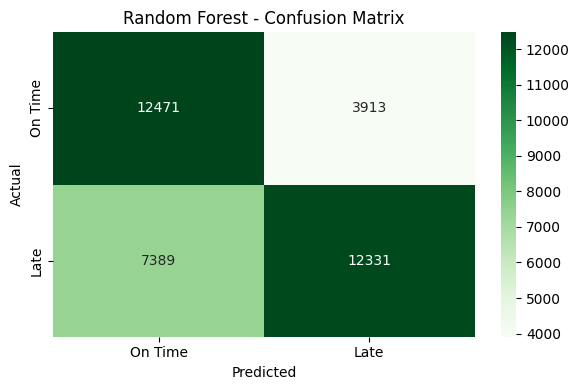

In [18]:
cm_rf = confusion_matrix(y_test2, rf_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['On Time', 'Late'],
            yticklabels=['On Time', 'Late'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/rf_confusion_matrix.png')
plt.show()

In [19]:
with open('../outputs/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Random Forest saved!")

Random Forest saved!


In [21]:
try:
    import xgboost as xgb
    print(f"XGBoost ready! Version: {xgb.__version__}")
except:
    print("XGBoost not installed!")
    print("Run in terminal: pip install xgboost")

XGBoost ready! Version: 3.2.0


In [22]:
from xgboost import XGBClassifier

# xgboost is generally the best performer for tabular data
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train2_scaled, y_train2)
print("XGBoost training done!")

XGBoost training done!


In [23]:
xgb_pred = xgb_model.predict(X_test2_scaled)
xgb_prob = xgb_model.predict_proba(X_test2_scaled)[:, 1]

print("=== XGBoost Results ===")
print(f"Accuracy:  {accuracy_score(y_test2, xgb_pred):.4f}")
print(f"Precision: {precision_score(y_test2, xgb_pred):.4f}")
print(f"Recall:    {recall_score(y_test2, xgb_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test2, xgb_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test2, xgb_prob):.4f}")

=== XGBoost Results ===
Accuracy:  0.6983
Precision: 0.8283
Recall:    0.5646
F1 Score:  0.6715
ROC-AUC:   0.7646


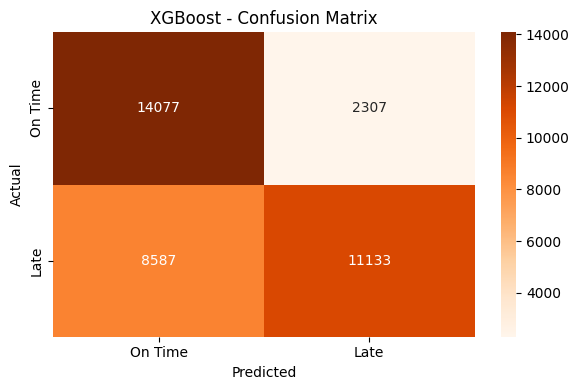

In [24]:
cm_xgb = confusion_matrix(y_test2, xgb_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['On Time', 'Late'],
            yticklabels=['On Time', 'Late'])
plt.title('XGBoost - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/xgb_confusion_matrix.png')
plt.show()

In [25]:
with open('../outputs/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("XGBoost saved!")

XGBoost saved!


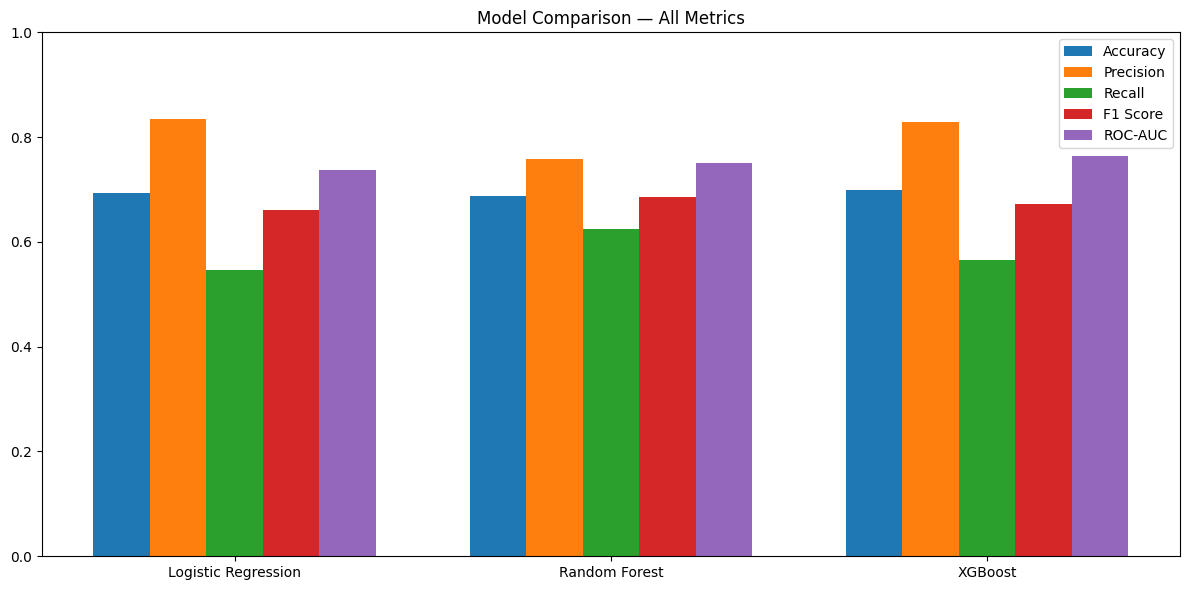

Comparison chart saved!


In [26]:
# final comparison chart for report
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
metrics = {
    'Accuracy':  [0.6934, 0.6870, 0.6983],
    'Precision': [0.8354, 0.7591, 0.8283],
    'Recall':    [0.5462, 0.6253, 0.5646],
    'F1 Score':  [0.6606, 0.6857, 0.6715],
    'ROC-AUC':   [0.7382, 0.7499, 0.7646]
}

x = np.arange(len(models))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6))

for i, (metric, values) in enumerate(metrics.items()):
    ax.bar(x + i * width, values, width, label=metric)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison — All Metrics')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()

print("Comparison chart saved!")